# T10 - Particiones en árboles de clasificación

## Gibrán Leonardo Chávez González

### Exp: 757366

### Fecha: 11 de mayo de 2026

## 1. Investiga los siguientes conceptos y su conexión con las particiones en árboles de clasificación:

1. GINI
2. Entropía
3. Log Loss
4. ¿Cuál es la diferencia entre entropía y log loss?

En árboles de regresión se busca una partición que reduzca la varianza conjunta o el error cuadrático dentro de los nodos. Sin embargo, en clasificación la variable de salida no es numérica continua, sino categórica. Por eso, en lugar de minimizar varianza, se usan medidas de **impureza** o **incertidumbre** del nodo, como **Gini**, **entropía** y, en algunos casos, **log loss**.

---

## 1. Gini

El **índice de Gini** mide qué tan mezcladas están las clases dentro de un nodo. Un nodo es más “puro” cuando la mayoría de sus observaciones pertenecen a una sola clase, y es más “impuro” cuando hay varias clases mezcladas en proporciones similares.

La fórmula general del índice de Gini es:

$$
G = \sum_{k=1}^{K} \hat{p}_{mk}(1-\hat{p}_{mk})
$$

También puede escribirse como:

$$
G = 1 - \sum_{k=1}^{K} \hat{p}_{mk}^{2}
$$

donde:

- $K$ es el número de clases.
- $\hat{p}_{mk}$ es la proporción de observaciones de la clase $k$ dentro del nodo $m$.

Si el valor de Gini es cercano a 0, el nodo es muy puro. Por ejemplo, si todas las observaciones pertenecen a una sola clase, entonces el Gini será 0. En cambio, si las clases están muy mezcladas, el valor de Gini será mayor.

En árboles de clasificación, el algoritmo prueba diferentes particiones y elige aquella que reduzca más la impureza de Gini en los nodos hijos. Es decir, busca que después del corte los grupos queden lo más separados posible según sus clases.

---

## 2. Entropía

La **entropía** también mide la impureza de un nodo, pero desde el punto de vista de la incertidumbre. Si en un nodo hay muchas clases mezcladas, existe más incertidumbre sobre qué clase debería predecirse. Si casi todas las observaciones pertenecen a la misma clase, la incertidumbre es baja.

La fórmula de la entropía es:

$$
H = -\sum_{k=1}^{K} \hat{p}_{mk}\log(\hat{p}_{mk})
$$

donde:

- $K$ es el número de clases.
- $\hat{p}_{mk}$ es la proporción de observaciones de la clase $k$ dentro del nodo $m$.
- El logaritmo puede estar en base 2 o en base natural.

La entropía es baja cuando el nodo es puro y alta cuando las clases están distribuidas de forma más equilibrada. En árboles de clasificación, se usa para calcular la **ganancia de información**, que representa cuánto se reduce la incertidumbre después de realizar una partición.

La ganancia de información se puede expresar como:

$$
IG = H(\text{padre}) - \left[
\frac{n_{izq}}{n}H(\text{izquierdo}) +
\frac{n_{der}}{n}H(\text{derecho})
\right]
$$

El árbol elige la partición que genere la mayor reducción de entropía, es decir, la mayor ganancia de información.

---

## 3. Log Loss

El **log loss**, también conocido como **pérdida logarítmica** o **cross-entropy loss**, mide qué tan buenas son las probabilidades predichas por un modelo de clasificación.

A diferencia de Gini y entropía, que se enfocan en medir la impureza de los nodos, el log loss evalúa qué tan bien el modelo asigna probabilidades a las clases correctas.

Para clasificación binaria, su fórmula es:

$$
LogLoss = -[y\log(\hat{p}) + (1-y)\log(1-\hat{p})]
$$

donde:

- $y$ es la clase real, que puede ser 0 o 1.
- $\hat{p}$ es la probabilidad predicha para la clase 1.

Si el modelo predice una probabilidad alta para la clase correcta, el log loss será bajo. Pero si el modelo asigna una probabilidad alta a una clase incorrecta, el log loss será muy alto.

Por ejemplo, no es lo mismo equivocarse con una probabilidad de 0.55 que equivocarse con una probabilidad de 0.99. El segundo caso se penaliza más porque el modelo estaba muy seguro de una predicción incorrecta.

En árboles de clasificación, el log loss se relaciona con las probabilidades que se asignan en las hojas. Por ejemplo, si una hoja tiene 80% de observaciones de la clase A y 20% de la clase B, el árbol puede predecir esas proporciones como probabilidades.

---

## 4. Diferencia entre entropía y log loss

Aunque la entropía y el log loss se parecen matemáticamente porque ambos usan logaritmos, no significan exactamente lo mismo.

La **entropía** mide la incertidumbre o impureza dentro de un nodo. Se calcula usando las proporciones reales de clases dentro de ese nodo. Por eso, se usa principalmente para decidir qué partición conviene hacer durante la construcción del árbol.

El **log loss**, en cambio, mide qué tan buenas son las probabilidades predichas por el modelo. No solo considera si el modelo se equivocó o acertó, sino también qué tan seguro estaba de su predicción.

---


## 2. Escoge un dataset y realiza el ejemplo de hacer una partición para cada uno de los criterios de decisión.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd
import numpy as numpy
import seaborn as sns

In [2]:
df = load_iris()
X = df.data
y = df.target

In [3]:
feature_names = df.feature_names
class_names = df.target_names

In [4]:
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
class_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### Gini

In [8]:
dtc_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

In [9]:
dtc_gini.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


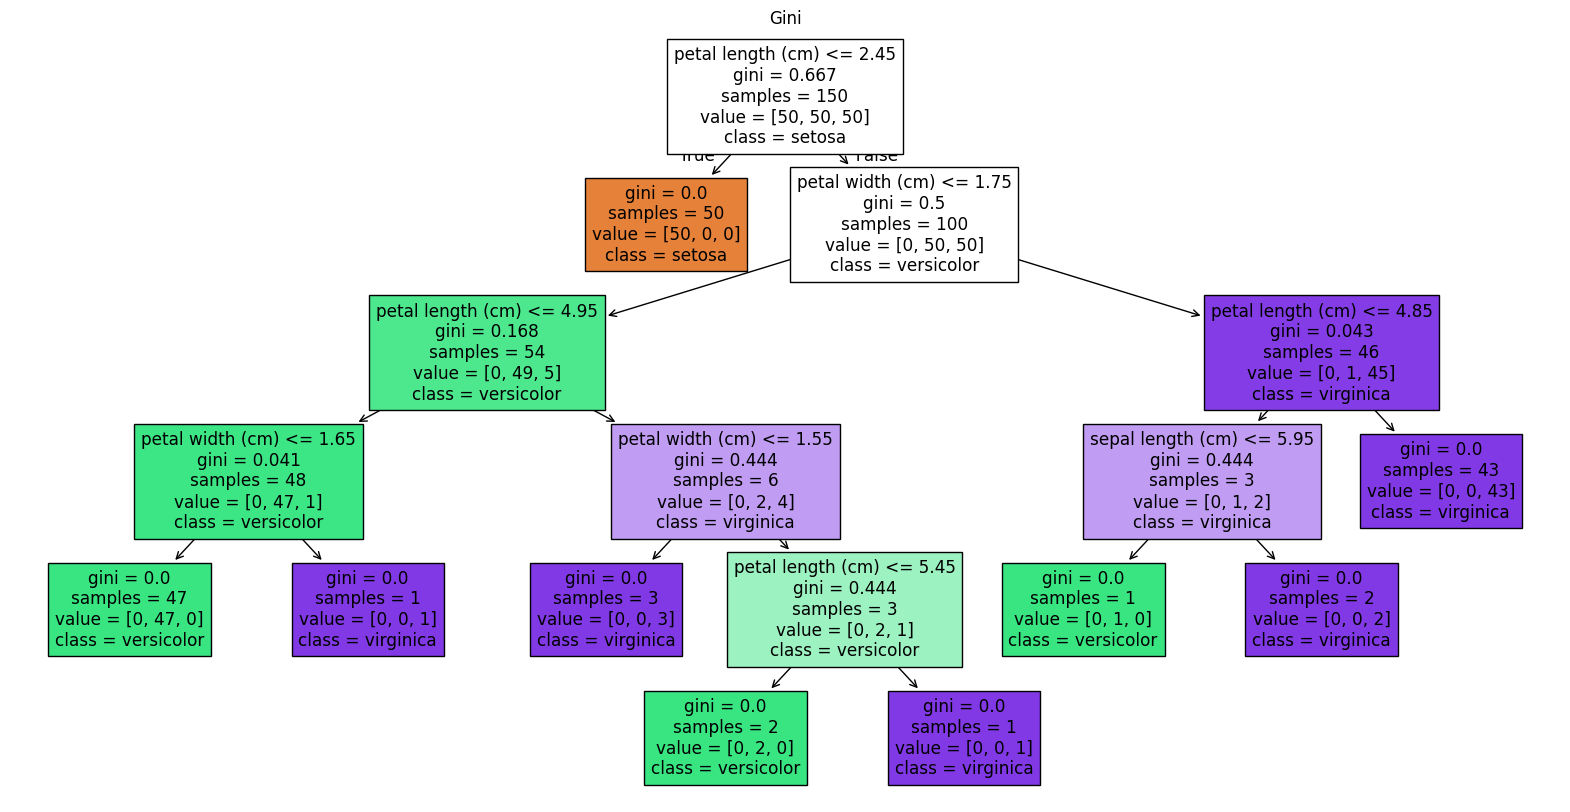

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(
    dtc_gini,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)
plt.title('Gini')
plt.show()

### Entropía

In [13]:
dtc_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

In [14]:
dtc_entropy.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


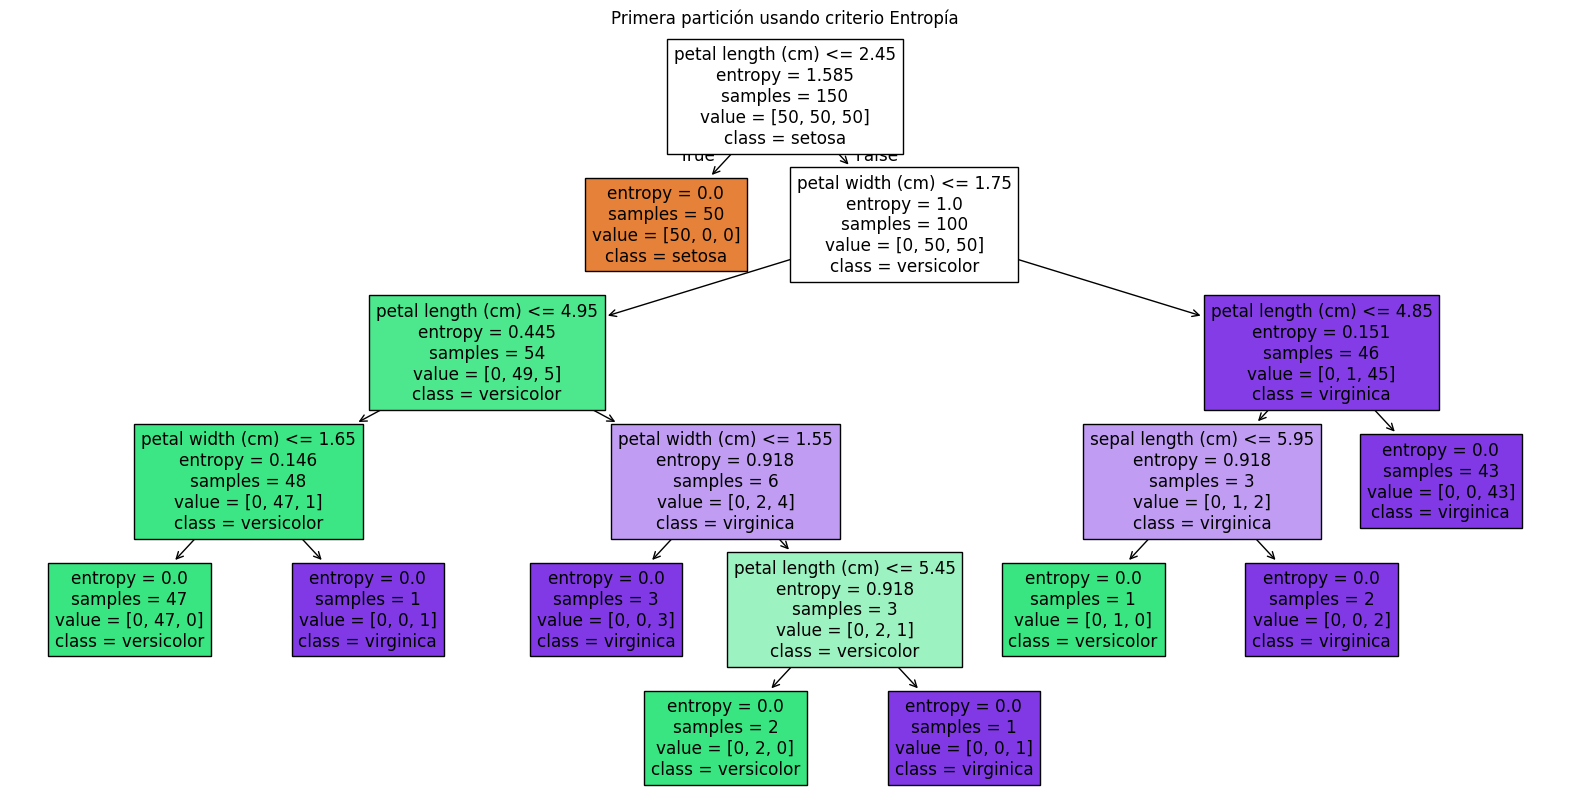

In [16]:
plt.figure(figsize=(20, 10))
plot_tree(
    dtc_entropy,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)
plt.title('Primera partición usando criterio Entropía')
plt.show()

### Log Loss

In [18]:
dtc_log_loss = DecisionTreeClassifier(
    criterion='log_loss',
    random_state=42
)

In [19]:
dtc_log_loss.fit(X, y)

,criterion,'log_loss'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


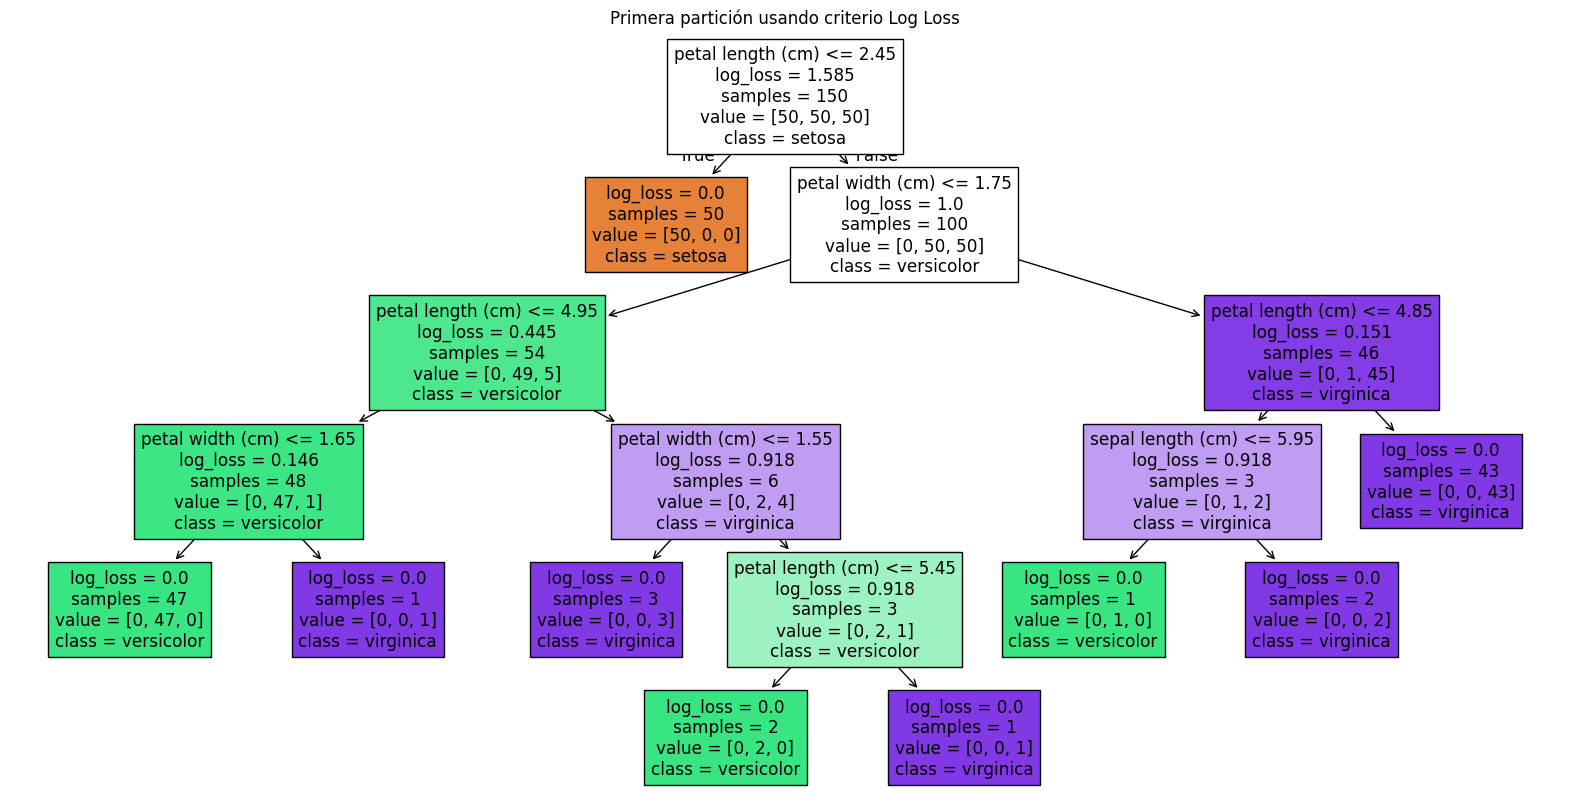

In [20]:
plt.figure(figsize=(20, 10))
plot_tree(
    dtc_log_loss,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)
plt.title('Primera partición usando criterio Log Loss')
plt.show()

# Interpretación de las gráficas del árbol de clasificación 

El dataset **Iris** contiene 150 flores divididas en tres clases:

- `setosa`
- `versicolor`
- `virginica`

Cada flor tiene cuatro variables predictoras:

- `sepal length (cm)`
- `sepal width (cm)`
- `petal length (cm)`
- `petal width (cm)`

En las gráficas se observa cómo el árbol va haciendo particiones para separar las flores según sus características.

---

## 1. Primera partición del árbol

En los tres criterios, la primera partición es:

$$
petal\ length \leq 2.45
$$

Esto significa que el árbol comienza separando las flores según el largo del pétalo.

En el nodo raíz aparecen 150 muestras:

```text
samples = 150
value = [50, 50, 50]
class = setosa
```

Esto indica que al inicio hay:

- 50 flores de clase `setosa`
- 50 flores de clase `versicolor`
- 50 flores de clase `virginica`

La primera partición divide los datos en dos grupos:

```text
petal length (cm) <= 2.45
```

Si esta condición es verdadera, el árbol clasifica directamente como `setosa`.

---

## 2. Separación de la clase setosa

El nodo izquierdo después de la primera partición tiene:

```text
samples = 50
value = [50, 0, 0]
class = setosa
```

Esto significa que las 50 observaciones que cumplen:

$$
petal\ length \leq 2.45
$$

son todas de la clase `setosa`.

Por eso, ese nodo tiene impureza igual a 0.

En Gini:

```text
gini = 0.0
```

En Entropía:

```text
entropy = 0.0
```

En Log Loss:

```text
log_loss = 0.0
```

Esto quiere decir que el nodo es completamente puro. No hay mezcla de clases.

---

## 3. Separación entre versicolor y virginica

Las flores que no cumplen la primera condición pasan al lado derecho del árbol:

```text
samples = 100
value = [0, 50, 50]
class = versicolor
```

Aquí ya no hay flores `setosa`. Solo quedan:

- 50 `versicolor`
- 50 `virginica`

Por eso, el árbol necesita hacer más particiones para separar estas dos clases.

La siguiente partición importante es:

$$
petal\ width \leq 1.75
$$

Esta variable ayuda a diferenciar entre `versicolor` y `virginica`.

---

## 4. Interpretación del lado izquierdo después de `petal width <= 1.75`

Cuando se cumple:

$$
petal\ width \leq 1.75
$$

el árbol llega a un nodo con:

```text
samples = 54
value = [0, 49, 5]
class = versicolor
```

Esto significa que en ese grupo hay:

- 49 flores `versicolor`
- 5 flores `virginica`

El árbol predice `versicolor` porque es la clase mayoritaria.

Aunque no es un nodo totalmente puro, sí tiene mayoría clara de `versicolor`.

---

## 5. Interpretación del lado derecho después de `petal width <= 1.75`

Cuando no se cumple la condición:

$$
petal\ width > 1.75
$$

el árbol obtiene un nodo con:

```text
samples = 46
value = [0, 1, 45]
class = virginica
```

Esto significa que en ese grupo hay:

- 1 flor `versicolor`
- 45 flores `virginica`

El árbol predice `virginica` porque es la clase dominante.

Este nodo es bastante puro, porque casi todas las observaciones pertenecen a `virginica`.

---

## 6. Qué significan `samples`, `value` y `class`

En cada nodo aparecen tres elementos importantes:

### `samples`

Indica cuántas observaciones llegaron a ese nodo.

Por ejemplo:

```text
samples = 150
```

significa que hay 150 flores en ese nodo.

### `value`

Indica cuántas observaciones hay de cada clase.

Por ejemplo:

```text
value = [50, 50, 50]
```

significa:

- 50 `setosa`
- 50 `versicolor`
- 50 `virginica`

Otro ejemplo:

```text
value = [0, 49, 5]
```

significa:

- 0 `setosa`
- 49 `versicolor`
- 5 `virginica`

### `class`

Indica la clase que predice el árbol en ese nodo.

Por ejemplo:

```text
class = versicolor
```

significa que, si una observación llega a ese nodo, el árbol la clasifica como `versicolor`.

La clase elegida es la que aparece con mayor frecuencia en `value`.

---

## 7. Qué significa la impureza en cada gráfica

Cada árbol muestra una medida diferente de impureza:

- `gini`
- `entropy`
- `log_loss`

Aunque cambie el nombre de la métrica, la idea es parecida: medir qué tan mezcladas están las clases dentro de cada nodo.

Un valor de impureza igual a 0 significa que el nodo es completamente puro.

Por ejemplo:

```text
gini = 0.0
value = [50, 0, 0]
```

significa que ese nodo solo tiene flores `setosa`.

En cambio, un nodo como:

```text
gini = 0.5
value = [0, 50, 50]
```

tiene mayor impureza porque contiene una mezcla equilibrada entre `versicolor` y `virginica`.

---

## 8. Comparación entre Gini, Entropía y Log Loss

En las gráficas, los tres criterios generaron prácticamente el mismo árbol.

Esto pasa porque el dataset Iris tiene una estructura bastante clara, especialmente para separar `setosa` usando el largo del pétalo.

La diferencia principal está en el valor de impureza que aparece en cada nodo:

| Criterio | Nodo raíz | Interpretación |
|---|---:|---|
| Gini | 0.667 | Mide mezcla de clases usando probabilidades al cuadrado |
| Entropía | 1.585 | Mide incertidumbre de la distribución de clases |
| Log Loss | 1.585 | Mide pérdida probabilística |

Se observa que **entropía y log loss dan los mismos valores** en estos árboles. Esto ocurre porque, para el criterio de partición en `DecisionTreeClassifier`, `log_loss` está muy relacionado con la entropía cuando se evalúan las probabilidades de clase dentro de los nodos.

---

## 9. Interpretación general

Las gráficas muestran que las variables relacionadas con el pétalo son las más importantes para clasificar las flores Iris.

La primera variable usada fue:

$$
petal\ length
$$

y después aparece frecuentemente:

$$
petal\ width
$$

Esto indica que el largo y ancho del pétalo son más útiles para separar las especies que las variables del sépalo.

En particular:

- `setosa` se separa fácilmente con `petal length <= 2.45`.
- `versicolor` y `virginica` son más parecidas entre sí.
- Para separar `versicolor` y `virginica`, el árbol usa principalmente `petal width` y después algunos cortes adicionales con `petal length` y `sepal length`.

---

## Conclusión

Las gráficas muestran que el árbol primero identifica una regla muy clara para separar `setosa`:

$$
petal\ length \leq 2.45
$$

Después, el árbol intenta separar `versicolor` y `virginica`, que son clases más parecidas. Para hacerlo, usa principalmente el ancho del pétalo:

$$
petal\ width \leq 1.75
$$


### Probemos ahora con otro dataset

In [24]:
from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [25]:
Default = load_data('Default')
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [28]:
num_cols = ['balance', 'income']
cat_cols = ['student']
target = 'default'

In [33]:
X2 = Default[num_cols + cat_cols]
y2 = Default[target]

In [34]:
cat_transformer = OneHotEncoder(
    drop='first'
)

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categoric', cat_transformer, cat_cols),
    ],
    remainder='passthrough'
)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y2,
    test_size=0.25,
    random_state=42,
    stratify=y # Divide los datos asegurándose de que tanto el conjunto de entrenamiento como el de prueba contengan la misma proporción
)

In [39]:
arboles = [dtc_gini, dtc_entropy, dtc_log_loss]
criterios = ['Gini', 'Entropía', 'Log Loss']

Criterio: Gini
Accuracy en train: 1.0
Accuracy en test: 0.9572


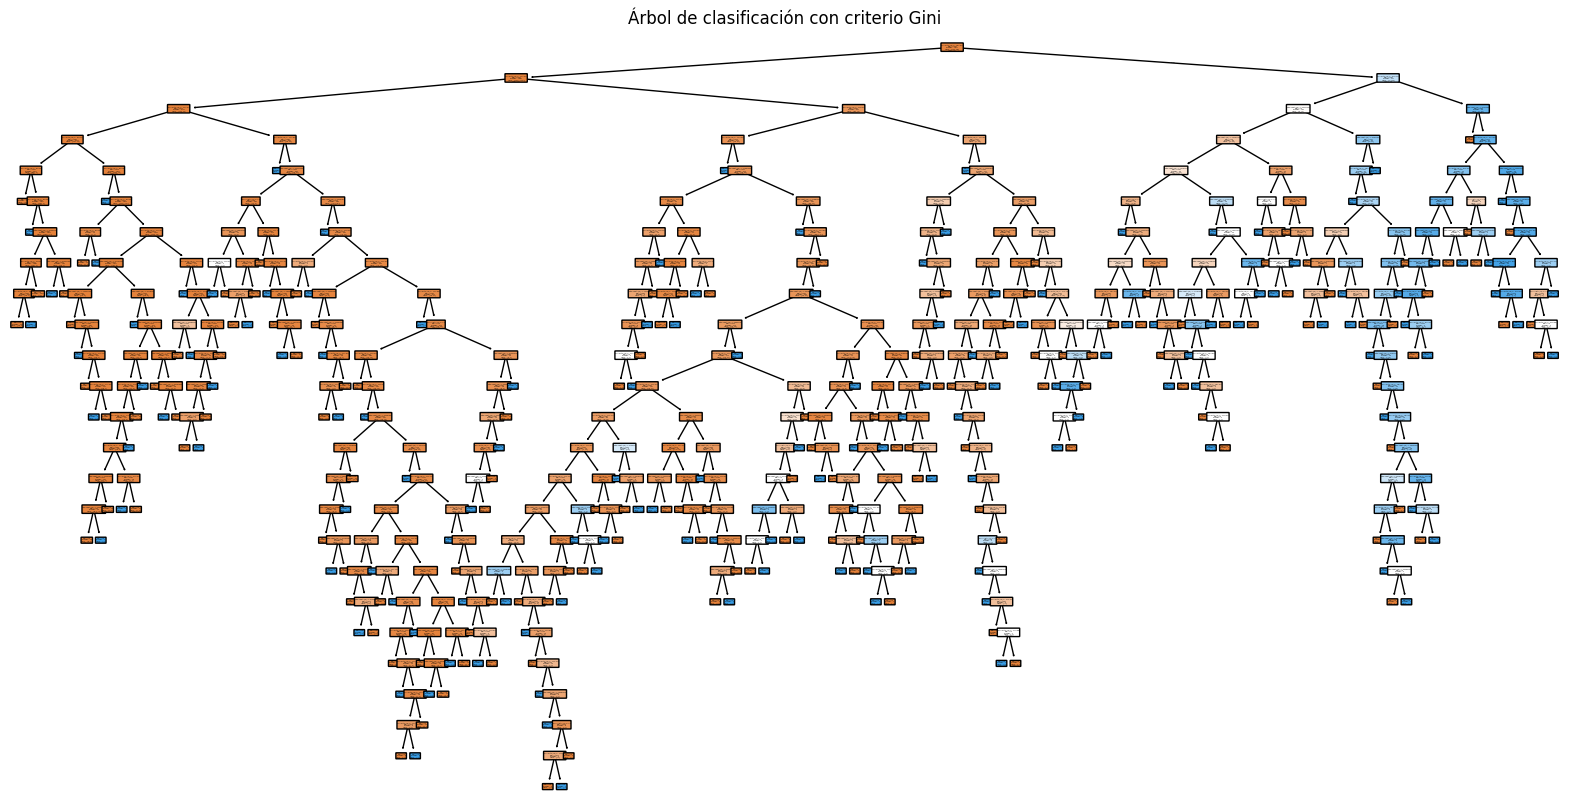

Criterio: Entropía
Accuracy en train: 1.0
Accuracy en test: 0.9552


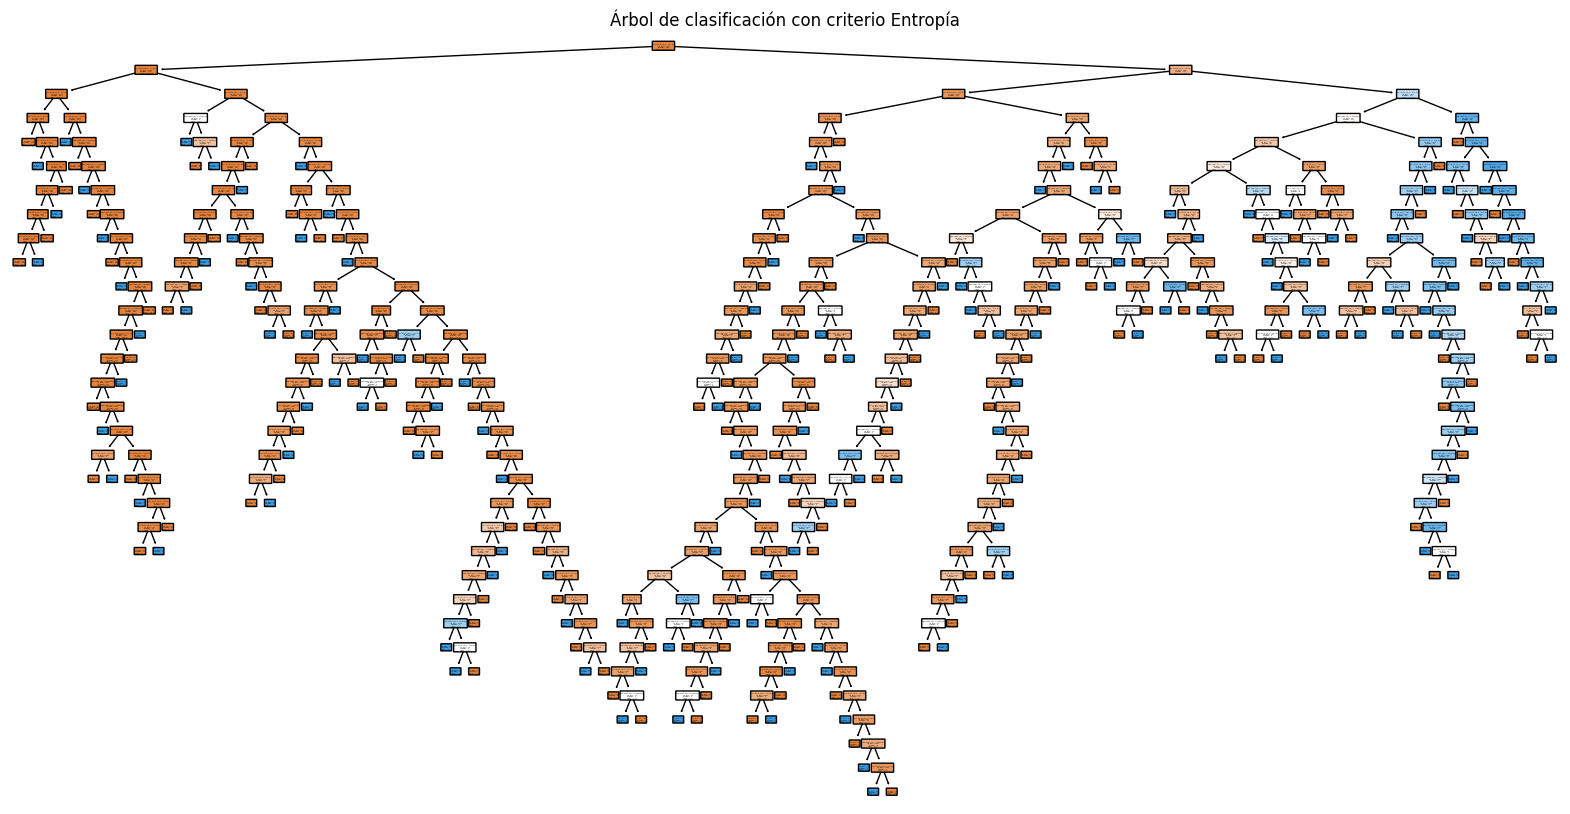

Criterio: Log Loss
Accuracy en train: 1.0
Accuracy en test: 0.9552


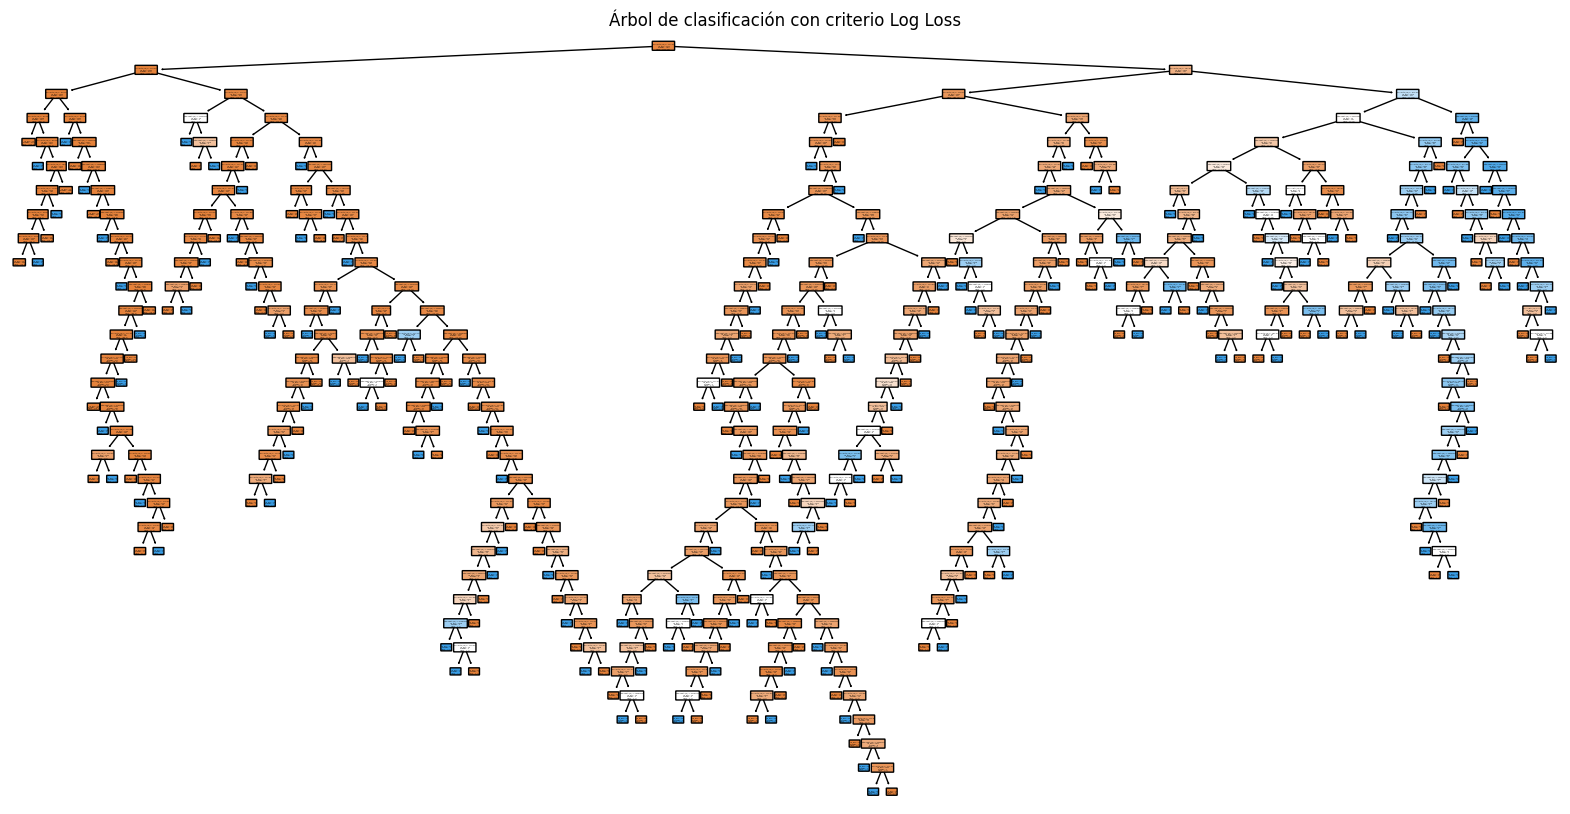

In [41]:
for tree, criterio in zip(arboles, criterios):
    print(f'Criterio: {criterio}')

    pipeline = Pipeline(
        steps=[
            ('transformer', preprocessor),
            ('model', tree)
        ]
    )

    pipeline.fit(X_train, y_train)
    print(f'Accuracy en train: {pipeline.score(X_train, y_train)}')
    print(f'Accuracy en test: {pipeline.score(X_test, y_test)}')
    plt.figure(figsize=(20, 10))

    plot_tree(
        pipeline.named_steps['model'],
        feature_names=feature_names,
        class_names=pipeline.named_steps['model'].classes_,
        filled=True,
        rounded=True
    )

    plt.title(f'Árbol de clasificación con criterio {criterio}')
    plt.show()

## Conclusión

Este ejemplo usa el dataset `Default` de la librería `ISLP`. A diferencia de Iris, aquí el problema es predecir si un cliente cae o no en default.

La variable objetivo es:

```python
default
```

Las variables predictoras usadas son:

```python
student
balance
income
```

El árbol aprende reglas de decisión para separar clientes con mayor o menor riesgo de default. En este dataset, probablemente la variable más importante sea `balance`, porque un saldo más alto suele estar relacionado con una mayor probabilidad de incumplimiento.

Al comparar los criterios `gini`, `entropy` y `log_loss`, se puede observar si los árboles hacen la misma primera partición o si cambian dependiendo de la medida de impureza utilizada.

## Referencias

Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and regression trees*. Wadsworth International Group.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer.

scikit-learn developers. (s. f.). *Decision trees*. scikit-learn User Guide. https://scikit-learn.org/stable/modules/tree.html

scikit-learn developers. (s. f.). *DecisionTreeClassifier*. scikit-learn API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

scikit-learn developers. (s. f.). *log_loss*. scikit-learn API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html

Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical Journal, 27*(3), 379–423; *27*(4), 623–656.